# MindMeter — Depression Risk Screen

**Habiba Farag Shehata · 2210018882**

End-to-end notebook. Re-running all cells will load the cleaned
dataset, retrain the bake-off, calibrate the winner, derive the
4-band risk tiers, and overwrite every artefact in the project
root.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from build_mindmeter_project import (
    PALETTE, TIER_EDGES, TIER_LABELS,
    clean, plot_eda, model_zoo, build_pipeline,
    fit_and_compare, calibrate_winner, plot_evaluation,
    assign_tiers, save_artefacts,
)

ROOT = Path('.').resolve()
print('Project root :', ROOT.name)

Project root : ML_Project_HabibaFarag


## 1. Load the cleaned dataset

In [2]:
df = clean()
print('shape:', df.shape)
print('positive rate:', f"{df['Depression'].mean():.2%}")
df.head()

shape: (140700, 18)
positive rate: 18.17%


,Gender,Age,City,Role,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,SuicidalThoughtsEver,WorkStudyHours,FinancialStress,FamilyHistory,Depression
0,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


## 2. EDA figures

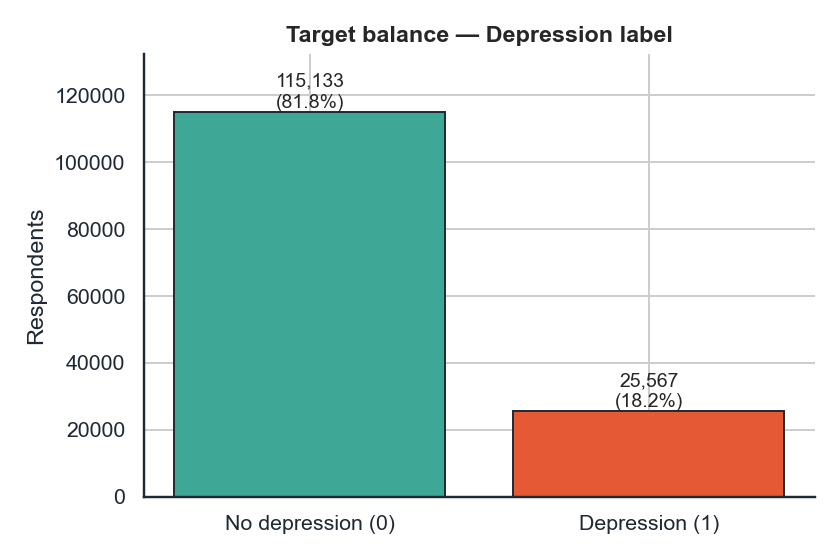

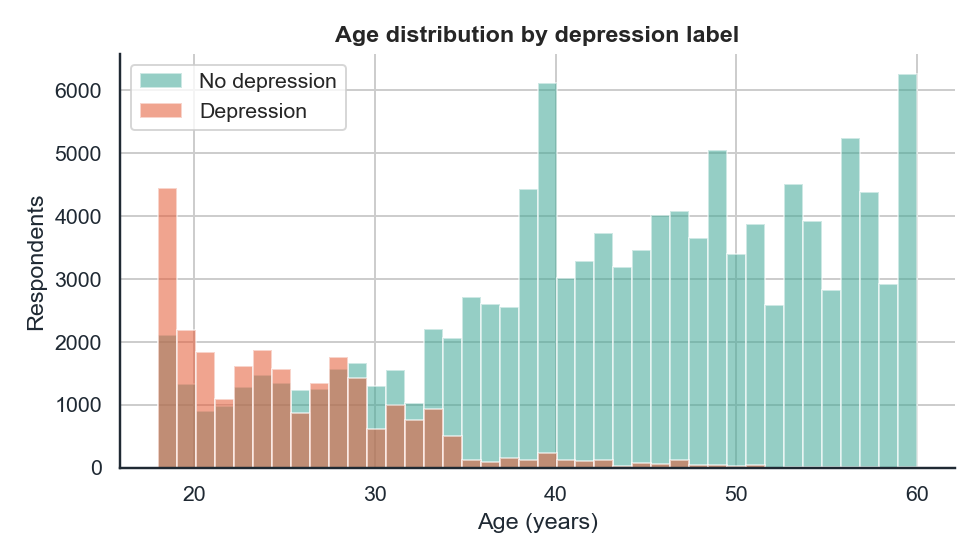

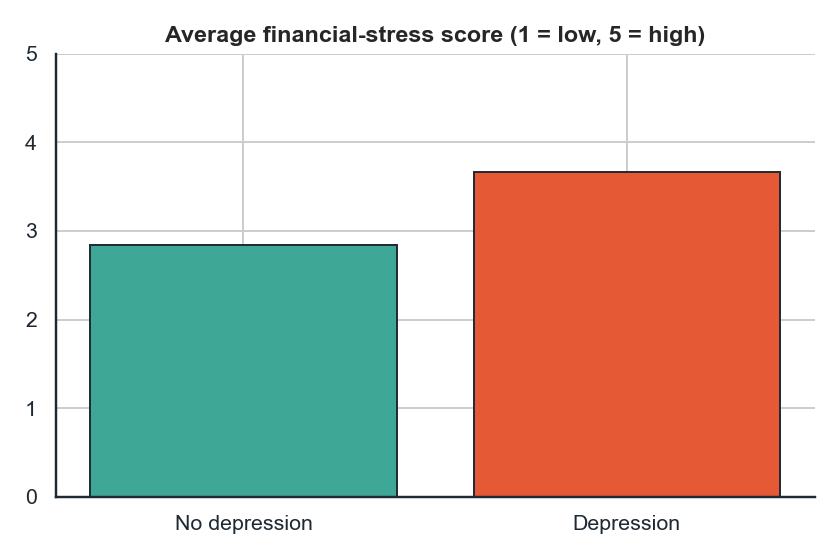

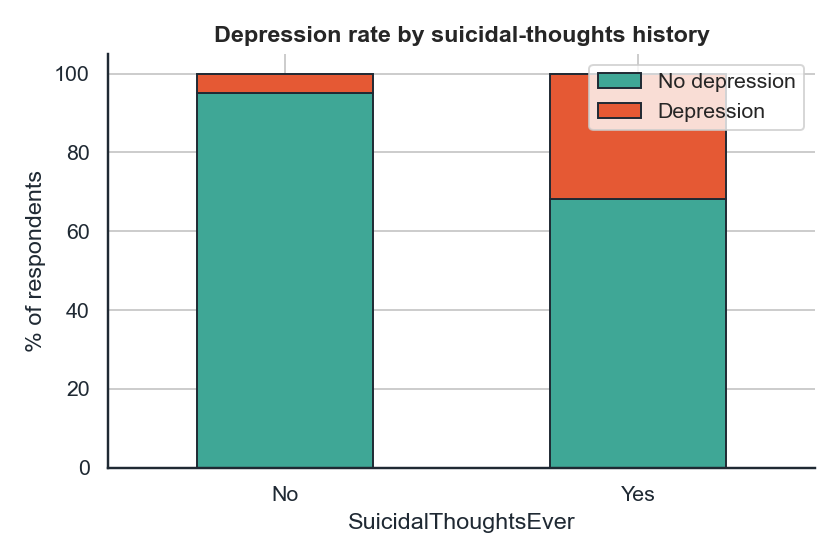

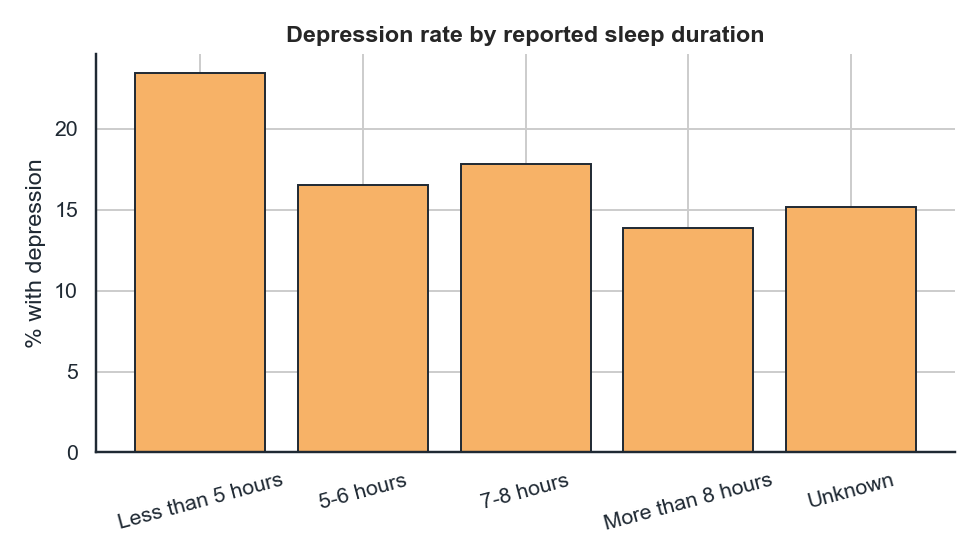

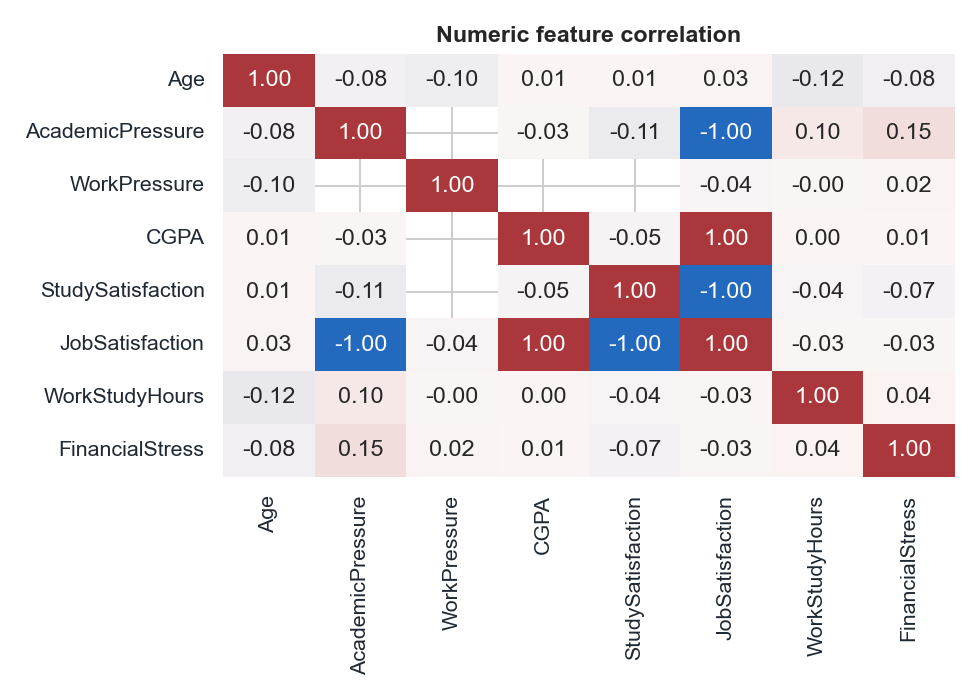

In [3]:
plot_eda(df)
from IPython.display import Image, display
for i in ('01_target_balance', '02_age_by_class',
         '03_financial_stress', '04_suicidal_history',
         '05_sleep_duration', '06_correlation_heatmap'):
    display(Image(filename=f'figures/{i}.png'))

## 3. Bake-off

In [4]:
comparison, fitted, X_tr, X_te, y_tr, y_te, feat = fit_and_compare(df)
comparison

  train=112,560   test=28,140   positive rate train=0.1817   test=0.1817
  fitting LogReg...


  fitting RandomForest...


  fitting GradBoost...


  fitting MLP...



  candidate comparison (ranked by ROC-AUC):
       model  accuracy  precision   recall       f1  roc_auc    brier
         MLP  0.937989   0.840753 0.812634 0.826455 0.973940 0.045249
      LogReg  0.915601   0.704146 0.923528 0.799052 0.973787 0.061809
   GradBoost  0.938131   0.848059 0.803442 0.825148 0.973666 0.045237
RandomForest  0.912473   0.699668 0.908077 0.790365 0.969003 0.067402


,model,accuracy,precision,recall,f1,roc_auc,brier
0,MLP,0.937989,0.840753,0.812634,0.826455,0.973940,0.045249
1,LogReg,0.915601,0.704146,0.923528,0.799052,0.973787,0.061809
2,GradBoost,0.938131,0.848059,0.803442,0.825148,0.973666,0.045237
3,RandomForest,0.912473,0.699668,0.908077,0.790365,0.969003,0.067402


## 4. Calibrate the winner and apply the 4-band tier map

In [5]:
winner = comparison.iloc[0]['model']
print('winner:', winner)
calibrated, proba_te, pred_te, final = calibrate_winner(
    winner, fitted, X_tr, y_tr, X_te, y_te,
)
tiers = assign_tiers(proba_te)
print('final metrics:', final)
pd.Series(tiers).value_counts().reindex(TIER_LABELS).rename('count')

winner: MLP


final metrics: {'accuracy': 0.9377398720682303, 'precision': 0.8540130608805562, 'recall': 0.7928808918443184, 'f1': 0.8223123732251522, 'roc_auc': 0.9739402849490431, 'brier': 0.047084500530318256}


Low         22677
Moderate      716
Elevated      746
High         4001
Name: count, dtype: int64

## 5. Evaluation figures

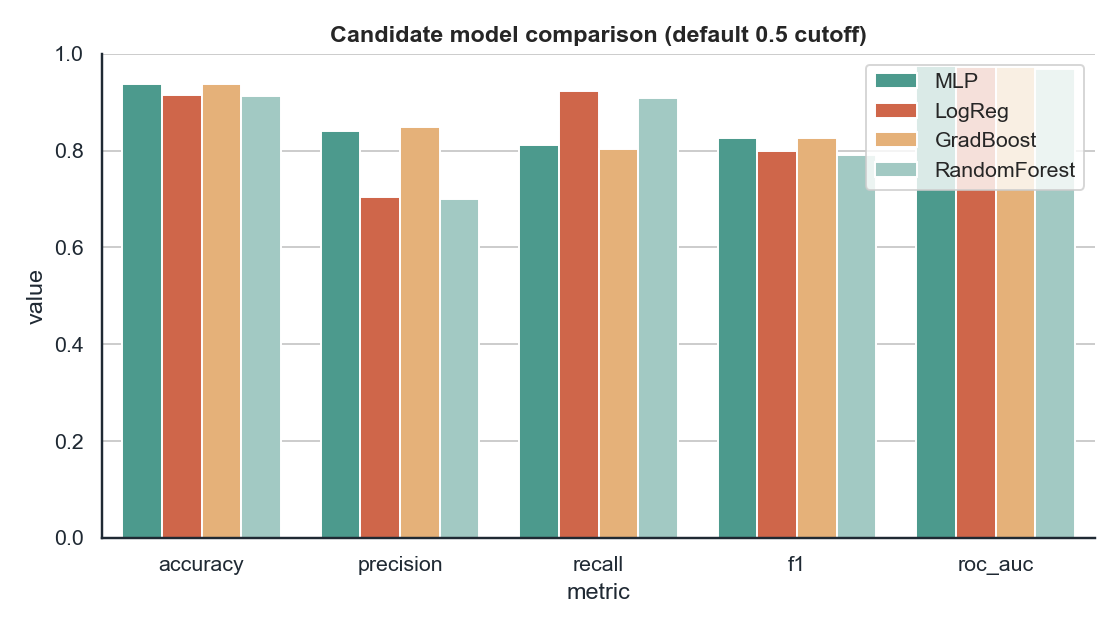

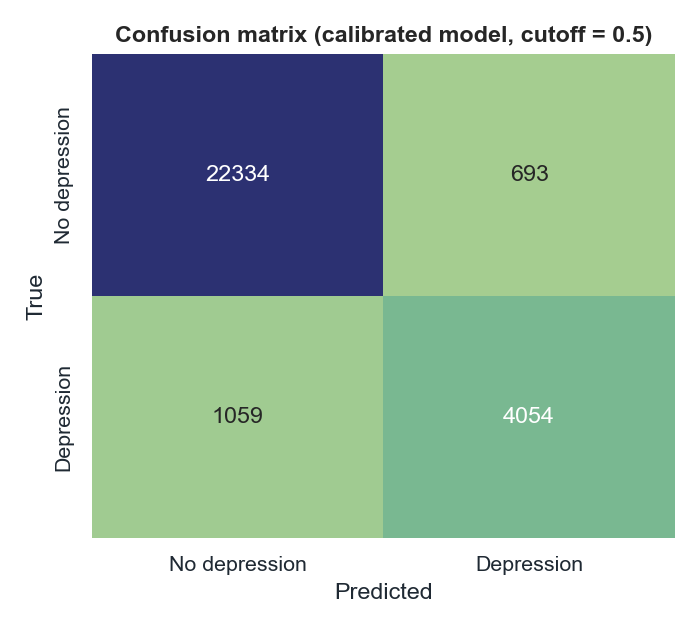

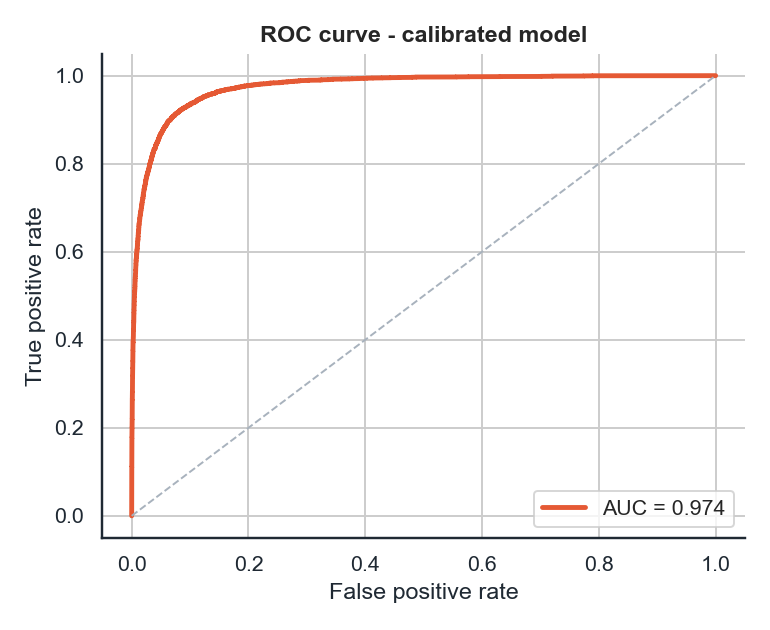

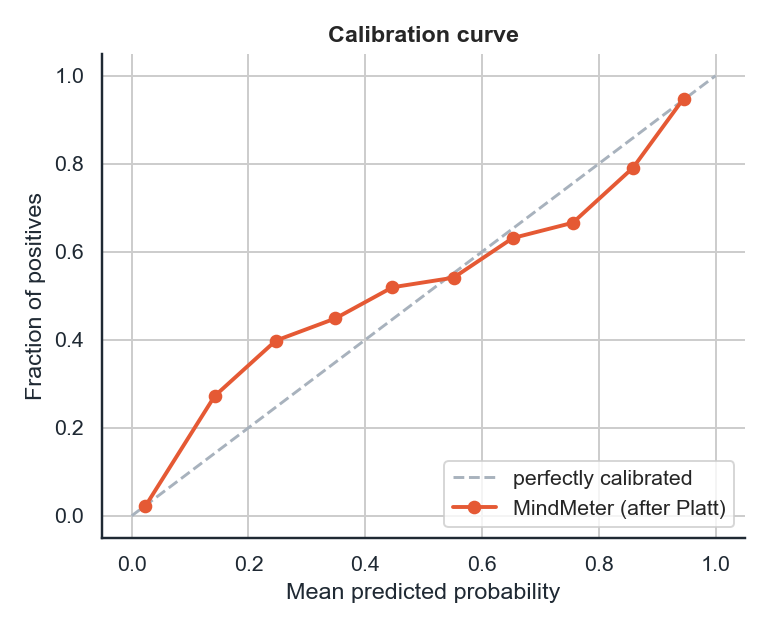

In [6]:
plot_evaluation(comparison, proba_te, pred_te, y_te)
from IPython.display import Image, display
for i in ('07_model_comparison', '08_confusion_matrix',
         '09_roc_curve', '10_calibration_curve'):
    display(Image(filename=f'figures/{i}.png'))

## 6. Save artefacts

In [7]:
save_artefacts(df, calibrated, feat, comparison, final, winner)


  artefacts saved:
   - mindmeter_model.pkl
   - mindmeter_features.pkl
   - mindmeter_tiers.json
   - mindmeter_metadata.json


## 7. Inference demo - reload everything from disk

In [8]:
model = joblib.load('mindmeter_model.pkl')
features = joblib.load('mindmeter_features.pkl')
tiers = json.loads(Path('mindmeter_tiers.json').read_text())

sample = df.sample(1, random_state=0)[features]
p = float(model.predict_proba(sample)[0, 1])
band = pd.cut([p], bins=tiers['edges'], labels=tiers['labels'],
              include_lowest=True)[0]
print(f'probability = {p:.3f}   tier = {band}')
sample.T

probability = 0.447   tier = Moderate


,117818
Gender,Male
Age,29.0
City,Jaipur
Role,Student
Profession,NaN
AcademicPressure,4.0
WorkPressure,NaN
CGPA,6.1
StudySatisfaction,1.0
JobSatisfaction,NaN
